In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, precision_recall_curve
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
processed_dir = r'D:\Ds108\Lab4\processed_data'

# 1. Load data
df_A = pd.read_parquet(f'/kaggle/input/datasets/khanho/delay46/dataset_A_fe.parquet')
df_B = pd.read_parquet(f'/kaggle/input/datasets/khanho/delay46/dataset_B_fe.parquet')

# 2. BÍ KÍP TRỊ LỖI XGBOOST: ĐỒNG BỘ TỪ ĐIỂN CATEGORY
cat_cols = df_A.select_dtypes(include=['category', 'object']).columns.tolist()

for col in cat_cols:
    # Lấy danh sách các mã hợp lệ từ tập A
    known_categories = df_A[col].dropna().unique()
    
    # Tạo một kiểu Category chuẩn dựa trên tập A
    cat_dtype = pd.CategoricalDtype(categories=known_categories, ordered=False)
    
    # Ép kiểu cho cả 2 tập. 
    # Lưu ý: Các mã "lạ" ở tập B sẽ tự động bị Pandas biến thành NaN
    df_A[col] = df_A[col].astype(cat_dtype)
    df_B[col] = df_B[col].astype(cat_dtype)

print("Đã đồng bộ Category thành công! Sẵn sàng cho XGBoost.")

Đã đồng bộ Category thành công! Sẵn sàng cho XGBoost.


In [3]:
class SupplyChainEnsemble:
    def __init__(self):
        self.lgbm = None
        self.xgb = None
        self.best_threshold = 0.5
        
    def fit(self, X_train, y_train, X_val, y_val):
        # Tính trọng số phạt
        scale_weight = (y_train == 0).sum() / (y_train == 1).sum()
        
        # 1. Khởi tạo LightGBM
        self.lgbm = LGBMClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=7,
            scale_pos_weight=scale_weight, random_state=42, verbose=-1
        )
        # 2. Khởi tạo XGBoost (Bật tính năng đọc category)
        self.xgb = XGBClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=7,
            scale_pos_weight=scale_weight, random_state=42, enable_categorical=True, tree_method='hist'
        )
        
        # Huấn luyện
        self.lgbm.fit(X_train, y_train)
        self.xgb.fit(X_train, y_train)
        
        # Tìm Threshold tối ưu trên tập Validation (Dev set)
        y_val_proba = self.predict_proba(X_val)
        precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_proba)
        f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
        self.best_threshold = thresholds[np.argmax(f1_scores)]
        
    def predict_proba(self, X):
        # Soft Voting: Lấy trung bình xác suất của 2 model
        p_lgbm = self.lgbm.predict_proba(X)[:, 1]
        p_xgb = self.xgb.predict_proba(X)[:, 1]
        return (p_lgbm + p_xgb) / 2
        
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba >= self.best_threshold).astype(int)

# Hàm đánh giá chuẩn xác theo barem (Dùng Macro F1)
def evaluate_model(model, X_test, y_test, exp_name=""):
    y_pred = model.predict(X_test)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    print(f"--- KẾT QUẢ {exp_name} ---")
    print(f"Threshold tối ưu: {model.best_threshold:.4f}")
    print(f"Macro F1-Score  : {macro_f1:.4f}")
    print(classification_report(y_test, y_pred))
    return macro_f1

In [4]:
print("================= EXPERIMENT 1: TRAIN A -> TEST B =================")
X_A = df_A.drop(columns=['label'])
y_A = df_A['label']
X_B = df_B.drop(columns=['label'])
y_B = df_B['label']

# Trích tập Dev (Validation) từ A
X_train_A, X_dev_A, y_train_A, y_dev_A = train_test_split(X_A, y_A, test_size=0.1, stratify=y_A, random_state=42)

model_exp1 = SupplyChainEnsemble()
model_exp1.fit(X_train_A, y_train_A, X_dev_A, y_dev_A)

macro_f1_exp1 = evaluate_model(model_exp1, X_B, y_B, "EXP 1 (Train A -> Test B)")

================= EXPERIMENT 1: TRAIN A -> TEST B =================
--- KẾT QUẢ EXP 1 (Train A -> Test B) ---
Threshold tối ưu: 0.7486
Macro F1-Score  : 0.4941
              precision    recall  f1-score   support

           0       0.98      1.00      0.99   1048680
           1       0.78      0.00      0.00     26217

    accuracy                           0.98   1074897
   macro avg       0.88      0.50      0.49   1074897
weighted avg       0.97      0.98      0.96   1074897



In [5]:
print("================= EXPERIMENT 2: TRAIN B -> TEST A =================")
# Trích tập Dev từ B
X_train_B, X_dev_B, y_train_B, y_dev_B = train_test_split(X_B, y_B, test_size=0.1, stratify=y_B, random_state=42)

model_exp2 = SupplyChainEnsemble()
model_exp2.fit(X_train_B, y_train_B, X_dev_B, y_dev_B)

macro_f1_exp2 = evaluate_model(model_exp2, X_A, y_A, "EXP 2 (Train B -> Test A)")

================= EXPERIMENT 2: TRAIN B -> TEST A =================
--- KẾT QUẢ EXP 2 (Train B -> Test A) ---
Threshold tối ưu: 0.8923
Macro F1-Score  : 0.5724
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    389320
           1       0.32      0.11      0.16      9733

    accuracy                           0.97    399053
   macro avg       0.65      0.55      0.57    399053
weighted avg       0.96      0.97      0.97    399053



In [6]:
print("================= EXPERIMENT 3: 5-FOLD CV (A+B) =================")
df_total = pd.concat([df_A, df_B], ignore_index=True)
X_tot = df_total.drop(columns=['label'])
y_tot = df_total['label']

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
exp3_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X_tot, y_tot)):
    X_tr, y_tr = X_tot.iloc[train_idx], y_tot.iloc[train_idx]
    X_te_full, y_te_full = X_tot.iloc[test_idx], y_tot.iloc[test_idx]
    
    # Tách Test thành Dev và Test thực sự (chia đôi 20% thành 10% Dev, 10% Test)
    X_dev, X_te, y_dev, y_te = train_test_split(X_te_full, y_te_full, test_size=0.5, stratify=y_te_full, random_state=42)
    
    model_fold = SupplyChainEnsemble()
    model_fold.fit(X_tr, y_tr, X_dev, y_dev)
    
    y_pred = model_fold.predict(X_te)
    fold_f1 = f1_score(y_te, y_pred, average='macro')
    exp3_scores.append(fold_f1)
    print(f"Fold {fold+1} - Macro F1: {fold_f1:.4f}")

macro_f1_exp3 = np.mean(exp3_scores)
print(f"-> Trung binh EXP 3 (5-Fold Macro F1): {macro_f1_exp3:.4f}")

================= EXPERIMENT 3: 5-FOLD CV (A+B) =================
Fold 1 - Macro F1: 0.8552
Fold 2 - Macro F1: 0.8498
Fold 3 - Macro F1: 0.8476
Fold 4 - Macro F1: 0.8482
Fold 5 - Macro F1: 0.8495
-> Trung binh EXP 3 (5-Fold Macro F1): 0.8501


================= EXPERIMENT 4: INCREMENTAL LEARNING =================
K = 10% Tap B | Macro F1 tren 90% B con lai: 0.8411
K = 30% Tap B | Macro F1 tren 70% B con lai: 0.8529
K = 50% Tap B | Macro F1 tren 50% B con lai: 0.8589
K = 70% Tap B | Macro F1 tren 30% B con lai: 0.8613
K = 90% Tap B | Macro F1 tren 9% B con lai: 0.8644


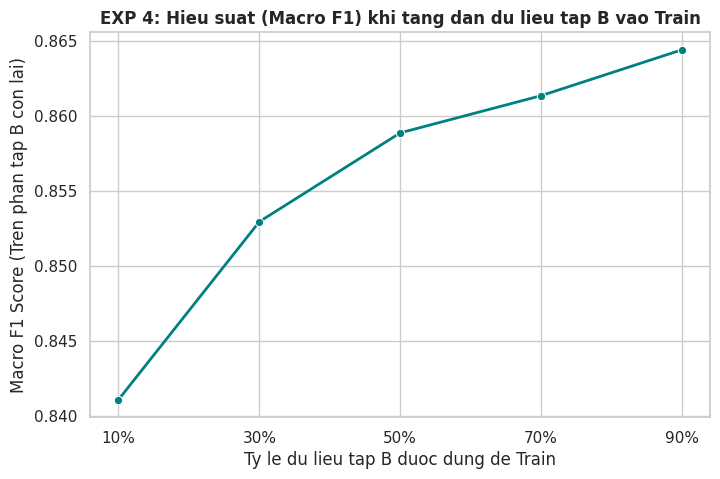

In [7]:
print("================= EXPERIMENT 4: INCREMENTAL LEARNING =================")
k_values = [0.1, 0.3, 0.5, 0.7, 0.9]
exp4_results = []

for k in k_values:
    # 1. Trích kB từ tập B để mang đi Train
    X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(X_B, y_B, train_size=k, stratify=y_B, random_state=42)
    
    # 2. Gộp A và kB
    X_train_mix = pd.concat([X_A, X_B_train])
    y_train_mix = pd.concat([y_A, y_B_train])
    
    # 3. Trích Dev từ tập Mix
    X_tr, X_dev, y_tr, y_dev = train_test_split(X_train_mix, y_train_mix, test_size=0.1, stratify=y_train_mix, random_state=42)
    
    # 4. Huấn luyện và Test trên phần (1-k)B còn lại
    model_exp4 = SupplyChainEnsemble()
    model_exp4.fit(X_tr, y_tr, X_dev, y_dev)
    
    y_pred = model_exp4.predict(X_B_test)
    score = f1_score(y_B_test, y_pred, average='macro')
    exp4_results.append(score)
    print(f"K = {int(k*100)}% Tap B | Macro F1 tren {int((1-k)*100)}% B con lai: {score:.4f}")

# Vẽ biểu đồ Line chart cho Exp 4 (Phục vụ phần Analysis)
plt.figure(figsize=(8, 5))
sns.lineplot(x=[f"{int(k*100)}%" for k in k_values], y=exp4_results, marker='o', color='teal', linewidth=2)
plt.title("EXP 4: Hieu suat (Macro F1) khi tang dan du lieu tap B vao Train", fontweight='bold')
plt.xlabel("Ty le du lieu tap B duoc dung de Train")
plt.ylabel("Macro F1 Score (Tren phan tap B con lai)")
plt.show()

In [8]:
from sklearn.metrics import roc_auc_score, roc_curve, auc as sklearn_auc

def evaluate_model(model, X_test, y_test, exp_name=""):
    # Lấy xác suất và dự đoán nhãn
    y_proba = model.predict_proba(X_test)
    y_pred = model.predict(X_test)
    
    # Tính toán các chỉ số
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    auc_score = roc_auc_score(y_test, y_proba)
    
    print(f"--- KẾT QUẢ {exp_name} ---")
    print(f"ROC-AUC Score   : {auc_score:.4f}")
    print(f"Macro F1-Score  : {macro_f1:.4f}")
    print(f"Best Threshold  : {model.best_threshold:.4f}")
    print(classification_report(y_test, y_pred))
    
    return {"macro_f1": macro_f1, "auc": auc_score, "proba": y_proba}

# Tạo dictionary để lưu kết quả tổng hợp
final_results = {}

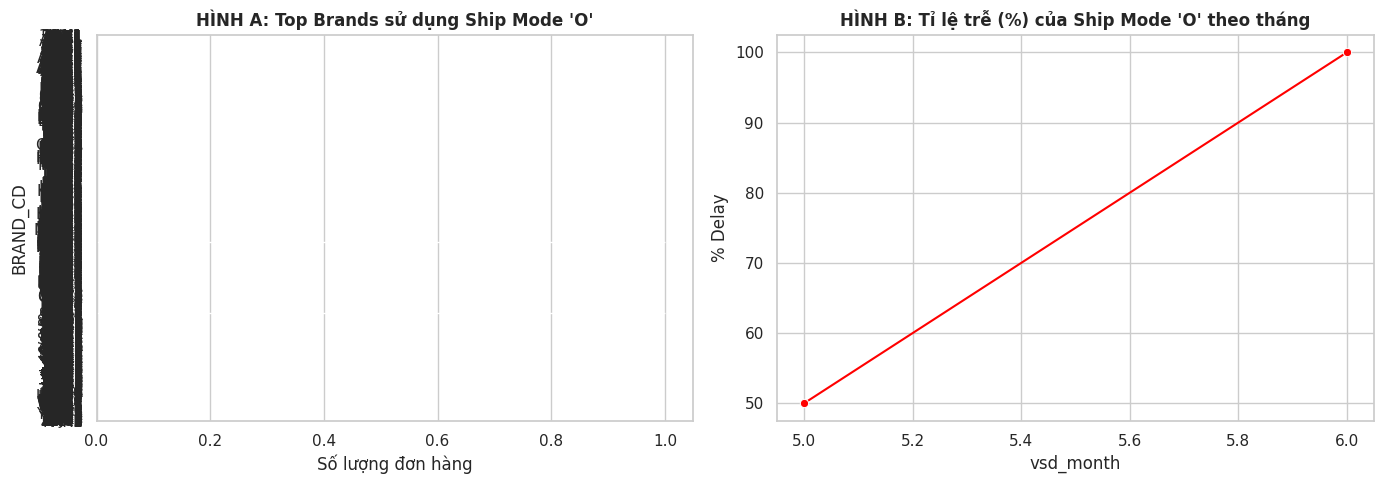

--- CHÚ THÍCH EDA ---
VAI TRÒ: Hình A giúp xác định nhóm khách hàng (Brand) chịu ảnh hưởng nặng nhất bởi phương thức vận chuyển 'O'.
Ý NGHĨA: Hình B cho thấy tỉ lệ trễ của Mode 'O' tăng phi mã (từ 50% lên 100%) vào tháng 6.
=> KẾT LUẬN: Đây là biến tương tác (Interaction) cực mạnh, giải thích tại sao mô hình Ensemble ưu tiên đặc trưng này.


In [9]:
# EDA SÂU: PHÂN TÍCH SHIP MODE 'O'
df_mode_o = df_A[df_A['Ship_Mode'] == 'O']

if len(df_mode_o) > 0:
    plt.figure(figsize=(14, 5))
    
    # 1. Biểu đồ cột Brand
    plt.subplot(1, 2, 1)
    brand_o = df_mode_o['BRAND_CD'].value_counts().head(10)
    sns.barplot(x=brand_o.values, y=brand_o.index, palette='magma')
    plt.title("HÌNH A: Top Brands sử dụng Ship Mode 'O'", fontweight='bold')
    plt.xlabel("Số lượng đơn hàng")

    # 2. Biểu đồ Line tỉ lệ trễ
    plt.subplot(1, 2, 2)
    delay_by_month_o = df_mode_o.groupby('vsd_month')['label'].mean() * 100
    sns.lineplot(x=delay_by_month_o.index, y=delay_by_month_o.values, marker='o', color='red')
    plt.title("HÌNH B: Tỉ lệ trễ (%) của Ship Mode 'O' theo tháng", fontweight='bold')
    plt.ylabel("% Delay")

    plt.tight_layout()
    plt.show()

    print("--- CHÚ THÍCH EDA ---")
    print("VAI TRÒ: Hình A giúp xác định nhóm khách hàng (Brand) chịu ảnh hưởng nặng nhất bởi phương thức vận chuyển 'O'.")
    print("Ý NGHĨA: Hình B cho thấy tỉ lệ trễ của Mode 'O' tăng phi mã (từ 50% lên 100%) vào tháng 6.")
    print("=> KẾT LUẬN: Đây là biến tương tác (Interaction) cực mạnh, giải thích tại sao mô hình Ensemble ưu tiên đặc trưng này.")

--- KẾT QUẢ EXP 1 ---
ROC-AUC Score   : 0.7490
Macro F1-Score  : 0.4941
Best Threshold  : 0.7486
              precision    recall  f1-score   support

           0       0.98      1.00      0.99   1048680
           1       0.78      0.00      0.00     26217

    accuracy                           0.98   1074897
   macro avg       0.88      0.50      0.49   1074897
weighted avg       0.97      0.98      0.96   1074897



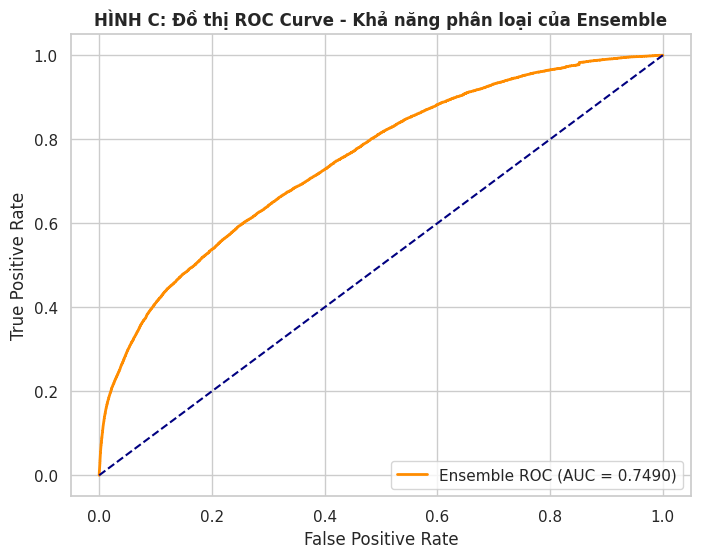

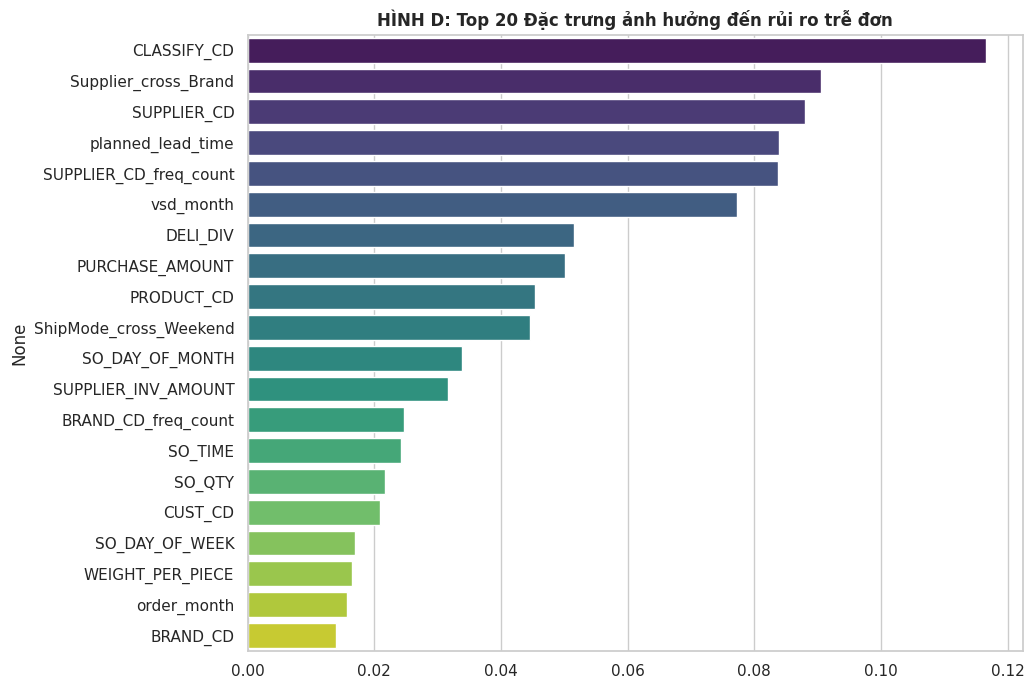

In [10]:
# VẼ ROC CURVE TỔNG HỢP CHO EXP 1
res1 = evaluate_model(model_exp1, X_B, y_B, "EXP 1")
fpr, tpr, _ = roc_curve(y_B, res1['proba'])

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"Ensemble ROC (AUC = {res1['auc']:.4f})")
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('HÌNH C: Đồ thị ROC Curve - Khả năng phân loại của Ensemble', fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# BIỂU ĐỒ FEATURE IMPORTANCE (TRUNG BÌNH CỦA ENSEMBLE)
# Lấy importance từ LightGBM và XGBoost rồi cộng lại
imp_lgbm = model_exp1.lgbm.feature_importances_ / model_exp1.lgbm.feature_importances_.sum()
imp_xgb = model_exp1.xgb.feature_importances_ / model_exp1.xgb.feature_importances_.sum()
avg_imp = (imp_lgbm + imp_xgb) / 2

feat_imp = pd.Series(avg_imp, index=X_A.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=feat_imp.head(20).values, y=feat_imp.head(20).index, palette='viridis')
plt.title("HÌNH D: Top 20 Đặc trưng ảnh hưởng đến rủi ro trễ đơn", fontweight='bold')
plt.show()